In [2]:
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
data_df = pd.read_csv("riceClassification.csv")

data_df.head(2)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1


In [4]:
data_df.dropna(inplace=True)
data_df.drop(["id"], axis=1, inplace=True)

In [5]:
print(data_df.shape)

(18185, 11)


In [6]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [7]:
original_df = data_df.copy()

for column in data_df.columns:
    data_df[column] = data_df[column] / data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
X = np.array(data_df.iloc[ : , : -1 ])
Y = np.array(data_df.iloc[ : , -1 ])

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

In [10]:
X_test, X_val, Y_test, Y_val = train_test_split(X_test, Y_test, test_size=0.5)


In [11]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [12]:
class Customdataset(Dataset):
    def __init__(self, X, Y):
        # convert the dataset to tensors
        self.X = torch.tensor(X, dtype=torch.float32).to(device)  # device is cpu for me
        self.Y = torch.tensor(Y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [13]:
training_data = Customdataset(X_train, Y_train)
validation_data = Customdataset(X_val, Y_val)
testing_data = Customdataset(X_test, Y_test)

In [14]:
batch_size = 32
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=batch_size, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=batch_size, shuffle=True)

In [15]:
HIDDEN_NUERONS = 10


class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_layer = nn.Linear(
            X.shape[1], HIDDEN_NUERONS
        )  # input features,hidden features
        self.linear = nn.Linear(HIDDEN_NUERONS, 1)  # hidden layer, output layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = MyModel().to(device)

In [16]:
summary(model,(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [17]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr = 1e-3)

In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = (
            ((prediction).round() == labels).sum().item()
        )  # to just get the single number of accuracy

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data
            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels)
            total_loss_val += batch_loss.item()
            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    total_loss_validation_plot.append(round(total_loss_val / 1000, 4))

    total_acc_train_plot.append(
        round(total_acc_train / training_data.__len__() * 100, 4)
    )
    total_acc_validation_plot.append(
        round(total_acc_val / validation_data.__len__() * 100, 4)
    )

    print(
        f"""
        Epoch no. : {epoch + 1}
        Train Loss : {round(total_loss_train / 1000, 4)}
        Train Accuracy : {round(total_acc_train / training_data.__len__() * 100, 4)}
        Validation Loss : {round(total_loss_val / 1000, 4)}
        Validation Accuracy : {round(total_acc_val / validation_data.__len__() * 100, 4)}
        """
    )
    print("="*20)



        Epoch no. : 1
        Train Loss : 0.2373
        Train Accuracy : 80.4855
        Validation Loss : 0.0391
        Validation Accuracy : 98.4604
        

        Epoch no. : 2
        Train Loss : 0.1209
        Train Accuracy : 98.1617
        Validation Loss : 0.0166
        Validation Accuracy : 98.1305
        

        Epoch no. : 3
        Train Loss : 0.0563
        Train Accuracy : 98.3974
        Validation Loss : 0.0093
        Validation Accuracy : 98.5704
        

        Epoch no. : 4
        Train Loss : 0.036
        Train Accuracy : 98.5073
        Validation Loss : 0.0066
        Validation Accuracy : 98.607
        

        Epoch no. : 5
        Train Loss : 0.0279
        Train Accuracy : 98.5781
        Validation Loss : 0.0054
        Validation Accuracy : 98.4604
        

        Epoch no. : 6
        Train Loss : 0.0238
        Train Accuracy : 98.5545
        Validation Loss : 0.0047
        Validation Accuracy : 98.607
        

        Epoch no. 

In [19]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in testing_dataloader:
        inputs,labels = data

        prediction = model(inputs).squeeze(1)
        
        batch_loss_test = criterion(prediction,labels).item()
        total_loss_test += batch_loss_test

        acc = ((prediction).round()==labels).sum().item()

        total_acc_test += acc

    print(f"Accuracy : {round(total_acc_test / testing_data.__len__() * 100, 4)}")

Accuracy : 98.6804


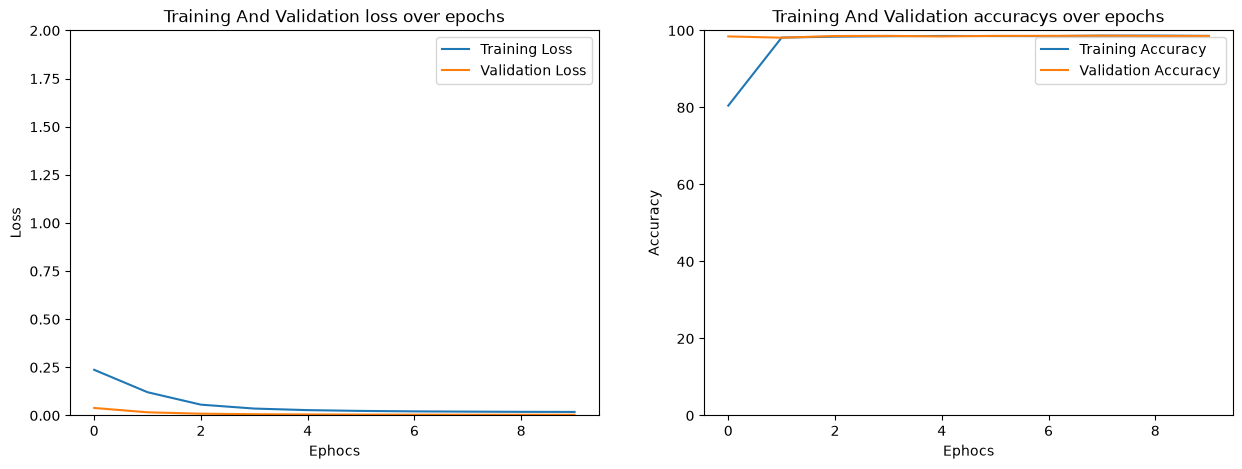

In [20]:
fix,axs = plt.subplots(nrows = 1,ncols = 2, figsize = (15,5))

axs[0].plot(total_loss_train_plot,label = "Training Loss")
axs[0].plot(total_loss_validation_plot,label = "Validation Loss")
axs[0].set_title("Training And Validation loss over epochs")
axs[0].set_xlabel("Ephocs")
axs[0].set_ylabel("Loss")
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label="Training Accuracy")
axs[1].plot(total_acc_validation_plot, label="Validation Accuracy")
axs[1].set_title("Training And Validation accuracys over epochs")
axs[1].set_xlabel("Ephocs")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim([0, 100])
axs[1].legend()


plt.show()

In [21]:
area = 2353 / original_df["Area"].abs().max()
MajorAxisLength = 81 / original_df["MajorAxisLength"].abs().max()
MinorAxisLength = 42 / original_df["MinorAxisLength"].abs().max()
Eccentricity = 32 / original_df["Eccentricity"].abs().max()
ConvexArea = 12 / original_df["ConvexArea"].abs().max()
EquivDiameter = 33 / original_df["EquivDiameter"].abs().max()
Extent = 98 / original_df["Extent"].abs().max()
Perimeter = 927 / original_df["Perimeter"].abs().max()
Roundness = 677 / original_df["Roundness"].abs().max()
AspectRation = 24 / original_df["AspectRation"].abs().max()


myprediction = model(
    torch.tensor(
        [
            area,
            MajorAxisLength,
            MinorAxisLength,
            Eccentricity,
            ConvexArea,
            EquivDiameter,
            Extent,
            Perimeter,
            Roundness,
            AspectRation,
        ],
        dtype=torch.float32,
    ).to(device)
)

print("Jasmine" if round(myprediction.item()) else "Gonen")

Gonen


In [22]:
# save - after training complete test.ipynb:682
import torch

torch.save(
    model, "rice_model.pt"
)  # full pickled model, ~few KB for 121 params test.ipynb:460
print("saved to rice_model.pt")


saved to rice_model.pt
